# Изучение рынка заведений общественного питания Москвы

- Автор: Дорохина Екатерина
- Дата: 27.07.26

### Цели и задачи проекта

Главной целью проекта является исследование рынка заведений общественного питания в Москве.<br>
На основе исследования будут определены наиболее подходящие локации для открытия точки инвесторов.

### Описание данных

В ходе исследования были использованы данные о заведениях Москвы и средних чеках рынка.

### Содержимое проекта

1. Знакомство с данными
2. Предобработка и корректировка данных
3. Исследовательская визуализация анализа
4. Итоги и рекомендации исследования

## 1. Загрузка данных и знакомство с ними

In [1]:
%pip install phik

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix 

In [3]:
# Выгружаем данные в переменную info_df
try:
    info_df = pd.read_csv('rest_info.csv')
except FileNotFoundError:
    info_df = pd.read_csv('/datasets/rest_info.csv')

In [4]:
# Выгружаем данные в переменную price_df
try:
    price_df = pd.read_csv('rest_price.csv') 
except FileNotFoundError:
    price_df = pd.read_csv('/datasets/rest_price.csv') 

In [5]:
# Посмотрим на вид данных info_df
info_df.head(3)

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0


In [6]:
# Посмотрим на вид данных price_df
price_df.head(3)

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0


In [7]:
# Выводим информацию об info_df
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [8]:
# Выводим информацию об price_df
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

В описании данных не было указано поле с id. Но оно есть и позволит нам объединять данные в дальнейшем.<br>
Все заголовки колонок в данных с ценами уже в подходящем змеином формате.

В info_df 9 колонок и 8406 строк.<br>
Пропуски есть в колонках hours и seats.<br>
Рейтингу и признаку сетевого заведения можно понизить разрядность.<br>
Число посадочных мест перевести в int64.<br>
Остальные типы соответствуют данным.

В price_df 5 колонок, 4058 строк.<br>
Пропуски есть везде, кроме колонки id. Самое большое кол-во в middle_coffee_cup.<br>
Типы данных им соответствуют.

### Подготовка единого датафрейма

Объединяю через left, чтобы не потерять большую часть данных о заведениях. Потому что в данных с ценами много пропусков.

In [9]:
# Объединиv данные двух датасетов в один
df = info_df.merge(price_df, on='id', how='left')

In [10]:
df.shape

(8406, 13)

Получили общий датафрейм на 8406 строк и 13 колонок.

## 2. Предобработка данных

In [11]:
# Понижаем разрядность рейтинга и признака сетевого заведения:
df['rating'] = df['rating'].astype('float32')
df['chain'] = df['chain'].astype('int8')

In [12]:
# Количество пропусков в колонках
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [13]:
# Доля пропусков в колонках, можно еще через df.isna().mean():
df.isna().sum() / len(df) * 100 

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

In [14]:
# Выведем уникальные адреса
df['address'].unique()

array(['Москва, улица Дыбенко, 7/1', 'Москва, улица Дыбенко, 36, корп. 1',
       'Москва, Клязьминская улица, 15', ...,
       'Москва, улица Лобачевского, 52, корп. 1',
       'Москва, Болотниковская улица, 52, корп. 2',
       'Москва, Чонгарский бульвар, 26А, корп. 1'], dtype=object)

In [15]:
# Выведем количество уникальных адресов
df['address'].nunique()

5753

In [16]:
# Выведем уникальные названия
df['name'].unique()

array(['WoWфли', 'Четыре комнаты', 'Хазри', ..., 'Миславнес', 'Самовар',
       'Kebab Time'], dtype=object)

In [17]:
# Выведем количество уникальных названий
df['name'].nunique()

5614

In [18]:
# Приведем названия к единому регистру
df['name'] = df['name'].str.lower()
df['name'].unique()

array(['wowфли', 'четыре комнаты', 'хазри', ..., 'миславнес', 'самовар',
       'kebab time'], dtype=object)

In [19]:
# Перепроверим количество уникальных названий
df['name'].nunique()

5512

Число уникальных названий снизилось после приведения имени к единому регистру: с 5614 до 5512.

In [20]:
# Проверяем неявные дубли
df.duplicated(subset=None, keep='first')

0       False
1       False
2       False
3       False
4       False
        ...  
8401    False
8402    False
8403    False
8404    False
8405    False
Length: 8406, dtype: bool

Число строк объединенного датафрейма не изменлось — неявных дублей нет.

In [21]:
# Посмотрим, как заполнена колонка hours
df['hours'].unique()

array(['ежедневно, 10:00–22:00',
       'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
       'ежедневно, 09:00–22:00', ...,
       'пн-пт 08:30–21:30; сб,вс 09:00–21:30',
       'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00',
       'пн-сб 10:30–21:30'], dtype=object)

In [22]:
# Определяем функцию, которая создаст новый столбец с бинарным признаком в зависимости от круглосуточного графика
def create_is_24_7(x):
    if x == 'ежедневно, круглосуточно':
        return True
    return False

In [23]:
# Создаём столбец is_24_7 с помощью функции create_is_24_7
df['is_24_7'] = df['hours'].apply(create_is_24_7)

In [24]:
# Рандомно проверим результат
df.sample(3)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
7680,eb7739f52c094a07a8482fc6ecfe754b,березка,"бар,паб","Москва, Дорожная улица, 42",Южный административный округ,"ежедневно, круглосуточно",1.1,0,30.0,NaN,NaN,NaN,NaN,True
5426,9b7a9af75a9541738bfbf82ed7db44fb,pizza wine,ресторан,"Москва, Рязанский проспект, 2/1к2А",Юго-Восточный административный округ,вт-вс 12:00–23:00,4.2,0,NaN,NaN,NaN,NaN,NaN,False
5223,eeda5eea724e45bca7f44f081e767392,волконский,булочная,"Москва, улица Большая Полянка, 44",Центральный административный округ,"пн-пт 08:00–21:00; сб,вс 08:00–20:00",4.5,1,NaN,NaN,NaN,NaN,NaN,False


---

### Промежуточный вывод

Типы данных соответствуют содержимому столбцов. Изменение типов не требуется. 

В данных присутствуют пропуски в столбцах hours, seats, price, avg_bill, middle_avg_bill и middle_coffee_cup. Скорее всего, это связано с отсутствием информации в источнике, а не с ошибками. Заполнение таких пропусков искусственными значениями может исказить результаты анализа, поэтому оставляем эти пропуски без изменений.

Количество уникальных названий и адресов меньше общего числа строк, что говорит о наличии повторяющихся названий и адресов. Это нормально в данном случае: одинаковые названия в осовном у сетевых заведений, а по одному адресу могут располагаться несколько разных заведений. Поэтому в этом анализе такие совпадения не являются основанием считать записи дубликатами и удалять их.

## 3. Исследовательский анализ данных

### Категории заведений

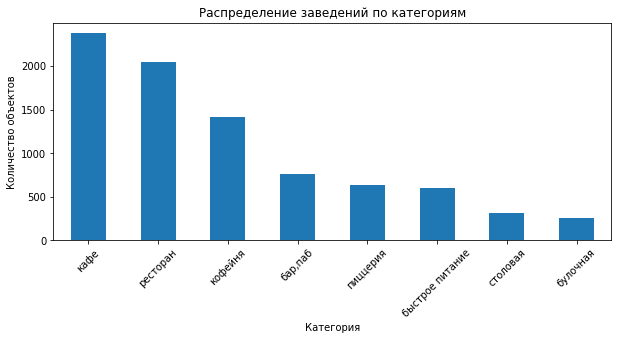

In [25]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['category'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=45, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение заведений по категориям'
)

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество объектов')
# Добавляем сетку графика
plt.grid(False)

# Выводим график
plt.show() 

Наиболее распространены кафе и рестораны, тогда как булочные и пиццерии встречаются значительно реже. Большая часть заведений сосредоточена в нескольких наиболее популярных категориях.

### Распределение по административным округам

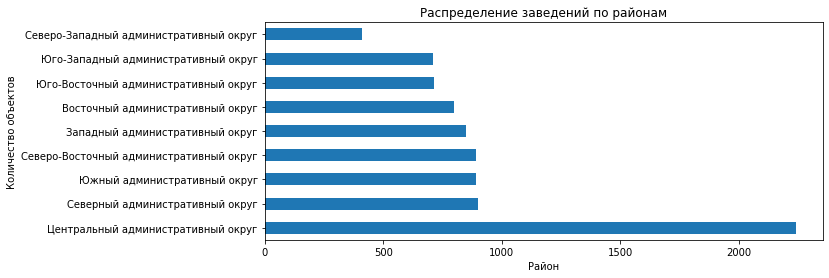

In [26]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['district'].value_counts().plot(
               kind='barh', # Тип графика - столбчатая диаграмма
               legend=False, # Выключаем легенду
               title=f'Распределение заведений по районам'
)

# Настраиваем оформление графика
plt.xlabel('Район')
plt.ylabel('Количество объектов')
# Добавляем сетку графика
plt.grid(False)

# Выводим график
plt.show() 

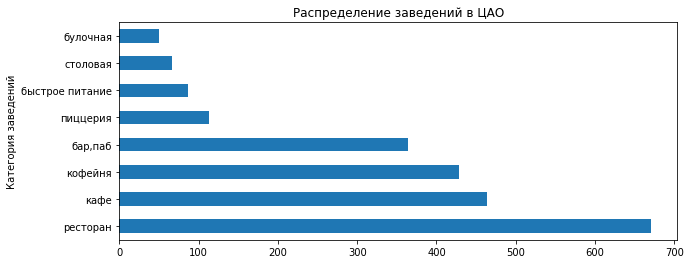

In [27]:
# Создаём контейнер графика matplotlib и задаём его размер

plt.figure(figsize=(10, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
# df[df['условие']]['нужный_столбец'] →
# → Из датафрейма оставь строки, удовлетворяющие условию, а затем возьми нужный столбец. 

df[df['district'] == 'Центральный административный округ']['category'].value_counts().plot(
               kind='barh', # Тип графика - столбчатая диаграмма
               legend=False, # Выключаем легенду
               title=f'Распределение заведений в ЦАО'
)

# Настраиваем оформление графика
plt.ylabel('Категория заведений')
# Добавляем сетку графика
plt.grid(False)

# Выводим график
plt.show() 

Среди районов по числу заведений лидирует ЦАО с отрывом более чем в 2 раза от остальных районов.<br>
Самыми распространенными в ЦАО являются рестораны. После них идут кафе и кофейни, далее бары и пабы. Остальные категории представлены в ЦАО в меньшей степени.

### Сетевые и несетевые заведения

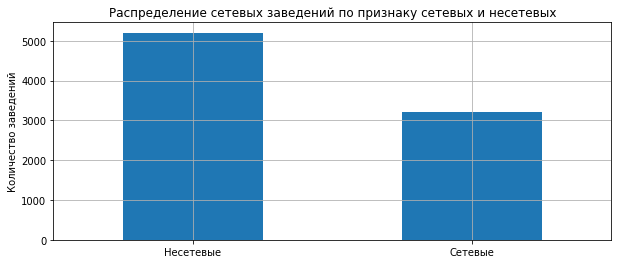

In [28]:
# Построим график столбчатой диаграммы
grouped = df['chain'].value_counts()
grouped.index = ['Несетевые', 'Сетевые']

grouped.plot(kind='bar',
               title='Распределение сетевых заведений по признаку сетевых и несетевых',
               ylabel='Количество заведений',
               legend=False,
               rot=0,
               figsize=(10, 4))
plt.grid()

# Выводим график
plt.show()

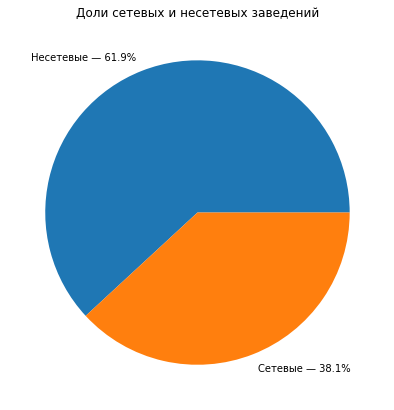

In [29]:
# Построим круговую диаграмму
grouped = df['chain'].value_counts()
grouped.index = ['Несетевые', 'Сетевые']
shares = grouped / grouped.sum() * 100

labels = [f'{name} — {share:.1f}%'
    for name, share in zip(grouped.index, shares)]

grouped.plot(
    kind='pie',
    title='Доли сетевых и несетевых заведений',
    labels=labels,
    ylabel='',
    legend=False,
    figsize=(7, 7))

# Выводим график
plt.show()

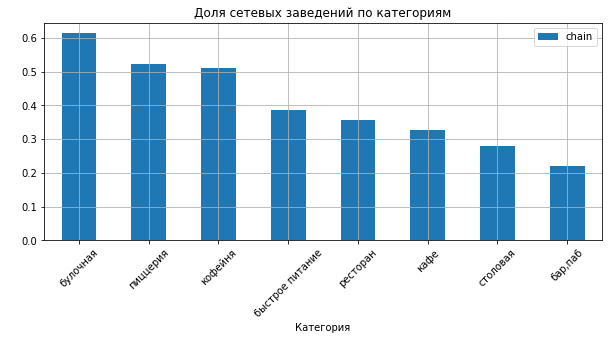

In [30]:
# Построим график столбчатой диаграммы
grouped = df.groupby('category')['chain'].mean().sort_values(ascending=False) 
grouped.plot(kind='bar',
               title='Доля сетевых заведений по категориям',
               legend=True,
               ylabel=' ',
               xlabel='Категория',
               rot=45,
               figsize=(10, 4))
plt.grid()

# Выводим график
plt.show()

В общем количестве сетевых заведений меньше на 60%, чем несетевых.<br>
При этом самый большой отрыв несетевых заведений — в категориях кафе и рестораны.<br>
Самое большое количество сетевых точек в категориях кафе, кофейни и рестораны.<br>
Среди булочных, кофеен и пиццерий сетевых заведений больше, чем несетевых.

### Посадочные места

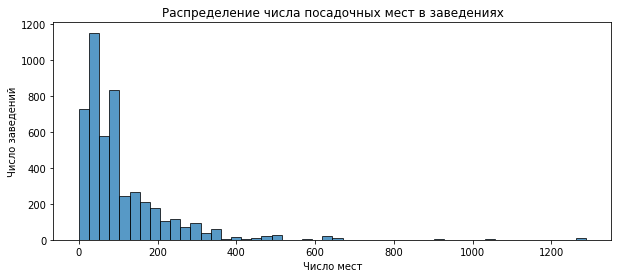

In [31]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 4))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['seats'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение числа посадочных мест в заведениях')
plt.xlabel('Число мест')
plt.ylabel('Число заведений')
# Убираем сетку графика
plt.grid(False)

# Выводим график
plt.show() 

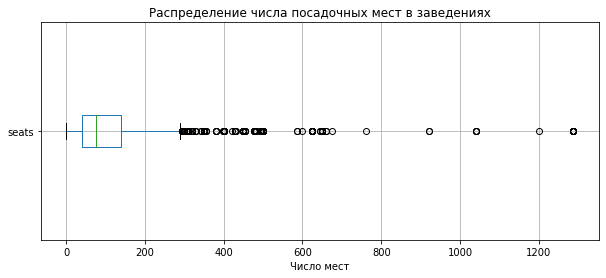

In [32]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 4))

# Строим диаграмму размаха значений в столбце seats
df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение числа посадочных мест в заведениях')
plt.xlabel('Число мест')

# Выводим график
plt.show() 

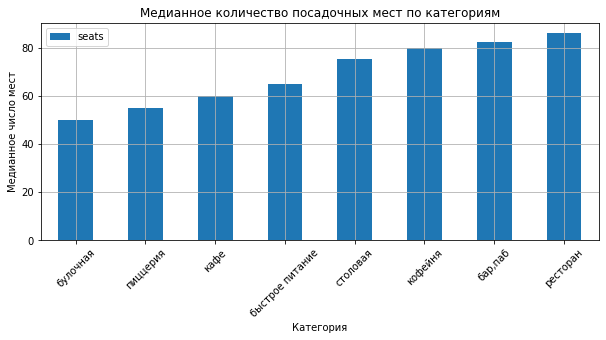

In [33]:
# Построим график столбчатой диаграммы с медианными значениями числа мест
grouped = df.groupby('category')['seats'].median().sort_values() 
grouped.plot(kind='bar',
               title='Медианное количество посадочных мест по категориям',
               legend=True,
               ylabel='Медианное число мест',
               xlabel='Категория',
               rot=45,
               figsize=(10, 4))
plt.grid()

# Выводим график
plt.show()

Распределение количества посадочных мест имеет длинный правый хвост. Большинство заведений рассчитано на небольшое число посетителей — до 50, однако встречаются отдельные заведения с очень большим количеством посадочных мест (свыше 500), которые можно считать выбросами. Такие значения могут быть связаны с крупными ресторанами с банкетными залами, большими столовыми или фудкортами.

### Рейтинг заведений

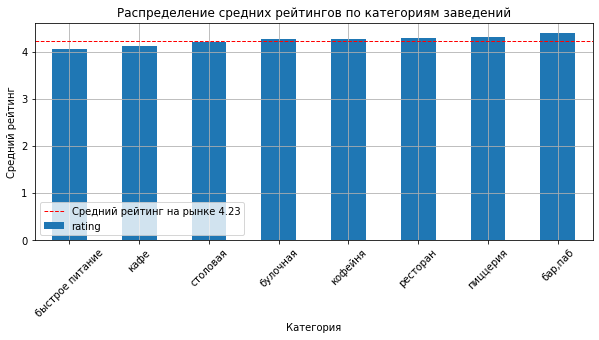

In [34]:
# Построим график столбчатой диаграммы 
grouped = df.groupby('category')['rating'].mean().sort_values() 
grouped.plot(kind='bar',
               title='Распределение средних рейтингов по категориям заведений',
               legend=False,
               xlabel='Категория',
               rot=45,
               figsize=(10, 4))

plt.ylabel('Средний рейтинг')
plt.grid()

# Рассчитываем среднее значение рейтинга
mean_rating_share = df['rating'].mean()

# Наносим на график линию со средним значением рейтинга в категориях
plt.axhline(mean_rating_share, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Средний рейтинг на рынке {mean_rating_share:.2f}')

plt.legend()

# Выводим график
plt.show()

Средние рейтинги разных категорий заведений отличаются незначительно. Большинство категорий имеют средний рейтинг около 4,2–4,4 звезды. Наиболее высокий средний рейтинг наблюдается у баров, пиццерий и ресторанов, а наиболее низкий — у заведений быстрого питания и кафе. В целом различия между категориями небольшие.

### Корреляция рейтинга с другими признаками

In [35]:
# Вычисляем корреляционную матрицу для рейтинга с использованием phi_k
correlation_matrix = df[['rating', 'category', 'district', 'chain', 'seats', 'price',
                         'hours']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False) 

interval columns not set, guessing: ['rating', 'chain', 'seats']


/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable hours is large: 1307. Are you sure this is not an interval variable? Analysis for pairs of variables including hours can be slow.
  warnings.warn(


Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.262056
category,0.198949
district,0.189389
chain,0.119071
seats,0.000000
hours,0.000000


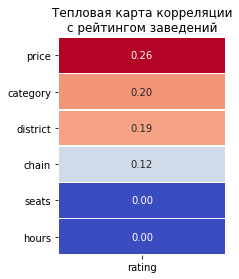

In [36]:
# Строим тепловую карту
plt.figure(figsize=(3, 4))

# Сохраняем матрицу корреляции 
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта корреляции\nс рейтингом заведений')

# Выводим график
plt.show() 

Наиболее сильная связь рейтинга наблюдается с ценовой категорией заведения, коэффициент корреляции составляет около 0,26. Но это все равно слабая связь. Остальные параметры (район, категория, круглосуточный режим работы, сетевой статус и количество посадочных мест) имеют еще более низкие значения коэффициента. Вывод: рейтинг заведений не имеет выраженной зависимости ни от одного из рассмотренных признаков.

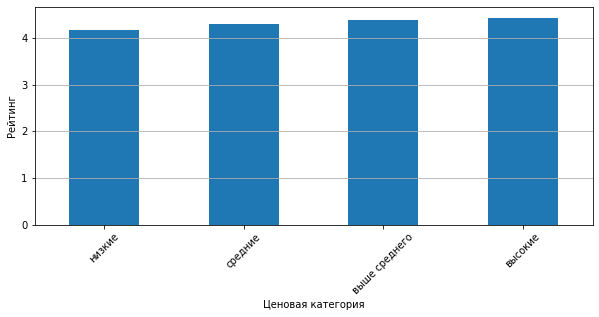

In [37]:
# Отобразим взаимосвязь рейтингов и ценовой категории заведений
grouped = (
    df.groupby('price')['rating']
      .mean()
      .sort_values()
)

grouped.plot(kind='bar',
            rot=45,
            xlabel='Ценовая категория',
            ylabel='Рейтинг',
            figsize=(10,4))

plt.grid(axis='y')

Видим, что средний рейтинг немного увеличивается по мере роста ценовой категории, однако различия между категориями невелики. Это подтверждает положительную, но слабую корреляцию между ценой и рейтингом.

### Топ-15 сетей Москвы

In [38]:
# Проверим статусы заведений
df[df['name'] == 'кафе'][['name', 'chain', 'category']].head()

,name,chain,category
40,кафе,0,кафе
47,кафе,0,кафе
108,кафе,0,"бар,паб"
123,кафе,0,кафе
141,кафе,0,кафе


In [39]:
# Построим график столбчатой диаграммы
grouped = df.groupby('name').agg({'rating':'mean',
                                 'id':'count',
                                 'category':'first'})

grouped = grouped.rename(columns={'id': 'count'})
grouped = grouped.sort_values(by='count', ascending=False)
top15 = grouped.head(15)

top15

,rating,count,category
name,,,
кафе,3.880952,189,кафе
шоколадница,4.177500,120,кофейня
домино'с пицца,4.171429,77,пиццерия
додо пицца,4.286487,74,пиццерия
one price coffee,4.069445,72,кофейня
яндекс лавка,3.872464,69,ресторан
cofix,4.075385,65,кофейня
prime,4.116000,50,ресторан
хинкальная,4.322727,44,быстрое питание


In [40]:
# Построим график столбчатой диаграммы с фильтрацией по сетевым точкам
grouped = df[df['chain'] == 1].groupby('name').agg({'rating':'mean',
                                 'id':'count',
                                 'category':'first'})

grouped = grouped.rename(columns={'id': 'count'})
grouped = grouped.sort_values(by='count', ascending=False)
top15 = grouped.head(15)

top15

,rating,count,category
name,,,
шоколадница,4.177500,120,кофейня
домино'с пицца,4.169737,76,пиццерия
додо пицца,4.286487,74,пиццерия
one price coffee,4.064789,71,кофейня
яндекс лавка,3.872464,69,ресторан
cofix,4.075385,65,кофейня
prime,4.116000,50,ресторан
хинкальная,4.322727,44,быстрое питание
кофепорт,4.147619,42,кофейня


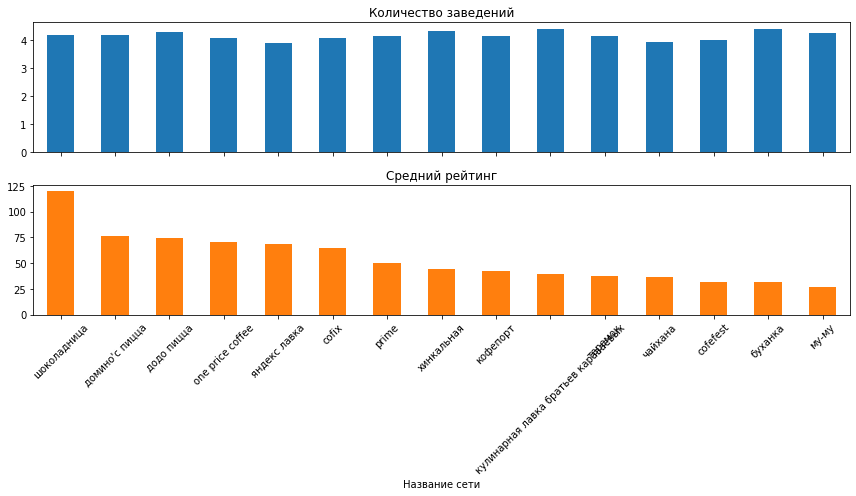

In [41]:
# Визуализируем на подграфиках
top15.plot(
    kind='bar',
    subplots=True,
    sharex=True,
    sharey=False,
    legend=False,
    figsize=(12, 7),
    title=['Количество заведений', 'Средний рейтинг']
)

plt.xticks(rotation=45)
plt.xlabel('Название сети')
plt.tight_layout()
plt.show()

Для поиска ТОП-15 сетей взяли только сетевые заведения, так как одинаковые названия несетевых заведений (например, «кафе») могли искажать результаты.<br>
Самой распространенной сетью в Москве является «Шоколадница» (120 заведений). Далее идут «Домино'с Пицца», «Додо Пицца», One Price Coffee, «Яндекс Лавка» и Cofix.<br>
В топ-15 преобладают кофейни, пиццерии и кафе.<br>
Средний рейтинг крупных сетей находится в диапазоне от 3,9 до 4,4 балла, что говорит о достаточно высокой оценке большинства.

### Средний чек по округам

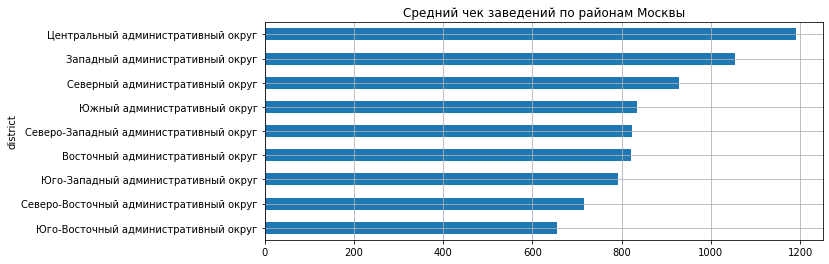

In [42]:
# Построим график столбчатой диаграммы 
grouped = df.groupby('district')['middle_avg_bill'].mean() 
grouped.sort_values(ascending=True).plot(kind='barh',
               title='Средний чек заведений по районам Москвы',
               legend=False,
               ylabel='Район',
               rot=0,
               figsize=(10, 4))

plt.grid()

# Выводим график
plt.show()

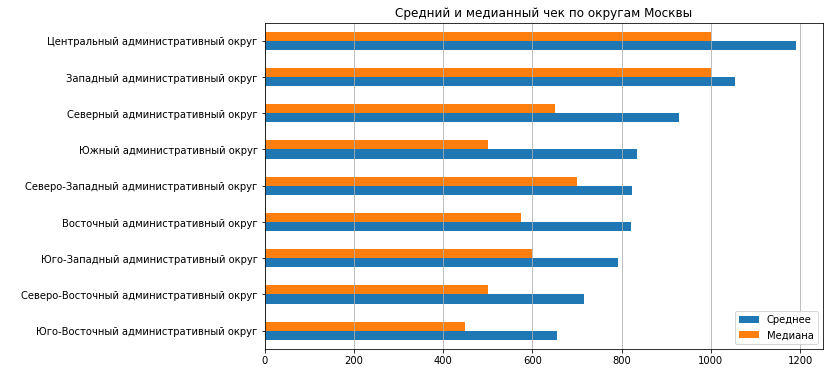

In [43]:
# Добавим барплот для сравненя цен внутри округа и между собой

grouped = (df.groupby('district')['middle_avg_bill']
      .agg(['mean', 'median'])
      .sort_values('mean'))

grouped.columns = ['Среднее', 'Медиана']

grouped.plot(
    kind='barh',
    figsize=(10, 6),
    title='Средний и медианный чек по округам Москвы',
    xlabel=' ',
    ylabel='Округ',
    rot=0)

plt.grid(axis='x')
plt.show()

---

### Промежуточный вывод

Средний чек существенно различается между административными округами Москвы. Самый высокий средний чек наблюдается в Центральном административном округе. Высокие значения также характерны для Западного и Северного административных округов, тогда как самые низкие — для Юго-Восточного и Северо-Восточного округов. В целом можно сделать вывод, что в центральных районах города средний чек выше, а по мере удаления от центра он, как правило, снижается.

## 4. Итоговый вывод и рекомендации

В ходе исследования были проанализированы данные о заведениях общественного питания Москвы. Была выполнена предобработка данных, изучены категории заведений, их распределение по административным округам, принадлежность к сетям, количество посадочных мест, рейтинг и средний чек.<br>
<br>
Исследование показало, что на рынке общественного питания Москвы преобладают кафе, рестораны и кофейни. Наибольшее количество заведений сосредоточено в Центральном административном округе, который также отличается самым широким разнообразием категорий заведений.<br>
<br>
Большинство заведений являются несетевыми, однако среди сетевых заведений лидирует «Шоколадница» (120 заведений). Далее следуют «Домино'с Пицца» (76), «Додо Пицца» (74), One Price Coffee (71), «Яндекс Лавка» (69) и Cofix (65). Среди крупнейших сетей преобладают кофейни, пиццерии и кафе. Средний рейтинг крупнейших сетей находится в диапазоне от 3,9 до 4,4 балла, что говорит о достаточно высокой оценке большинства из них.<br>
<br>
Анализ вместимости показал, что число посадочных мест существенно различается в зависимости от категории заведений, поэтому для сравнения категорий более показательна медиана, чем среднее значение. Большинство заведений рассчитано на вместимость 50-80 посетителей. Распределение имеет длинный правый хвост: встречаются отдельные крупные заведения с числом мест свыше 500.<br>
<br>
Средний чек заметно различается между административными округами. Наиболее высокий средний чек наблюдается в ЦАО (около 1200 рублей), а минимальные значения в ЮВАО (около 650 рублей). В целом прослеживается тенденция: по мере удаления от центра города средний чек, как правило, снижается.

При выборе места для открытия нового заведения следует учитывать различия между районами.<br>
Центральный административный округ подходит для заведений среднего и высокого ценового сегмента, а в более удалённых районах целесообразно ориентироваться на более доступный уровень цен.<br>
Также при анализе конкурентов стоит учитывать не только высокую распространённость сетевых кофеен и пиццерий, но и несетевые заведения, которых на рынке довольно много.